## **Datasets - Fraud Detection:**
https://www.kaggle.com/datasets/whenamancodes/fraud-detection/data

#### **Data Description:**

The dataset contains transactions made by credit cards in September 2013 by European cardholders. This dataset presents transactions that occurred in two days, and is highly imbalanced, the positive class (frauds) account for 0.172% of all transactions.

Due to privacy and confidentiality issues, the original features are recoded to features `V1`, `V2`, … `V28` via PCA, and appears to be normalized. '`Time` and `Amount` remain un-transformed. `Time` contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature `Amount` is the transaction Amount. The target feature `Class` is the response variable and it takes value 1 in case of fraud and 0 otherwise.
Provenance:

The dataset was collected during a research collaboration between Worldline and Machine Learning Group (http://mlg.ulb.ac.be) of ULB (Université Libre de Bruxelles) on big data mining and fraud detection.

#### **Motivation:**

Detecting fraudulent transactions among millions of legitimate ones is a high-stakes imbalanced classification problem. This project aims to develop a robust machine learning model to detect fraudulent credit card transactions, addressing the challenge of a highly imbalanced dataset (0.172% fraud rate).

Given the extreme class imbalance, our strategy prioritizes maximizing Recall to minimize undetected fraud. To ensure a practical balance between sensitivity and precision, we will optimize the F1-score and utilize AUPRC (Area Under the Precision-Recall Curve) as our primary evaluation metric, as it provides a more robust performance measure than Accuracy or ROC-AUC in this context.

#### **Challenges We Foresee:**

- *Asymmetric Data Distribution:* The extreme 0.172% fraud prevalence necessitates a stratified splitting strategy to ensure that both training and validation sets remain representative of the minority class and avoid data leakage.

- *Feature Engineering Constraints:* Due to the PCA-anonymized nature of features `V1` - `V28`, traditional domain-driven feature engineering is restricted. We must instead rely on automated feature selection and latent relationship modeling to enhance predictive power.

## **Exploratory Data Analysis**

### Preparation:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install gdown

import gdown
gdown.download("https://drive.google.com/uc?id=10CNYxjR-oyrvwdX5nBCEdJ64cqjGk-NR", "creditcard.csv", quiet=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Downloading...
From (original): https://drive.google.com/uc?id=10CNYxjR-oyrvwdX5nBCEdJ64cqjGk-NR
From (redirected): https://drive.google.com/uc?id=10CNYxjR-oyrvwdX5nBCEdJ64cqjGk-NR&confirm=t&uuid=5f404b6c-7340-4e92-876c-ea0a72b14aef
To: /content/creditcard.csv
100%|██████████| 151M/151M [00:01<00:00, 140MB/s]


'creditcard.csv'

This section is not part of the exploratory data analysis (EDA) itself; instead, it ensures the code runs smoothly in the Google Colab environment. First, the code imports and mounts Google Drive, allowing direct access to files stored in your Drive within the notebook. This simplifies file management and avoids the need for repeated manual uploads.

Next, the code installs and imports gdown, a utility that enables downloading files directly from shared Google Drive links. It is then used to retrieve the creditcard.csv dataset. The provided link is configured with appropriate permissions, so anyone with access to the link can view and download the file without additional setup.

### Dataset Overview

In [ ]:
import pandas as pd

fraud_file = pd.read_csv('/content/creditcard.csv')
print('Dataset Overview:')
fraud_file.head()

Dataset Overview:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


The dataset was loaded using pandas and inspected using the .head() function to view the first five rows. This provides an initial understanding of the data structure, feature types, and overall organization.

The dataset contains 31 columns, including:
*   Time: Transaction timestamp (relative to the first transaction), measured as the seconds elapsed between each transaction and the first recorded transaction
*   V1–V28: Anonymized features resulting from a PCA transformation (to protect sensitive information); these features appear to be normalized and are not directly interpretable
* Amount: Transaction amount
* Class: Target variable, where 0 indicates a legitimate transaction and 1 indicates fraud

### Dataset Shape & Types

In [ ]:
#Dataset Shape
print('Dataset Shape:')
print(fraud_file.shape)

# #Dataset Types
print('\nDataset Data Types:')
print(fraud_file.dtypes)

Dataset Shape:
(284807, 31)

Dataset Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


The dataset consists of 284,807 rows and 31 columns, indicating a relatively large dataset suitable for training and evaluating machine learning models.

An inspection of the data types shows that:
*   All feature columns (Time, V1–V28, and Amount) are of type float64
*   The target variable (Class) is of type int64




### Missing Values and Duplicates

In [ ]:
#Missing Values
print('\nMissing Values:')
print(fraud_file.isna().sum())


Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [ ]:
#Duplicates
print('\nDuplicates:')
print(fraud_file.duplicated().sum())


Duplicates:
1081


An analysis of missing values shows that no columns contain null or missing data, indicating a complete dataset with no immediate need for imputation or data cleaning in this regard.

The dataset was also checked for duplicate records, revealing 1,081 duplicated rows. While the presence of duplicates is not inherently problematic, it is important to distinguish between:

*   Legitimate repeated transactions (e.g., similar amounts occurring at close time intervals)
*   Exact duplicate rows, which may indicate redundant data entries

Since the .duplicated() function identifies exact row matches across all columns, these duplicates are likely true redundancies rather than coincidental similarities in features like Amount or Time.

Overall, the dataset is structurally sound due to the absence of missing values. However, the presence of duplicate records suggests that a decision should be made—either to remove them to avoid potential bias in modeling or retain them if they are deemed meaningful for the analysis.

### Class & Amount Distribution

In [ ]:
#Class Distribution
print('\nClass Distribution:')
print(fraud_file['Class'].value_counts(normalize=True))


Class Distribution:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


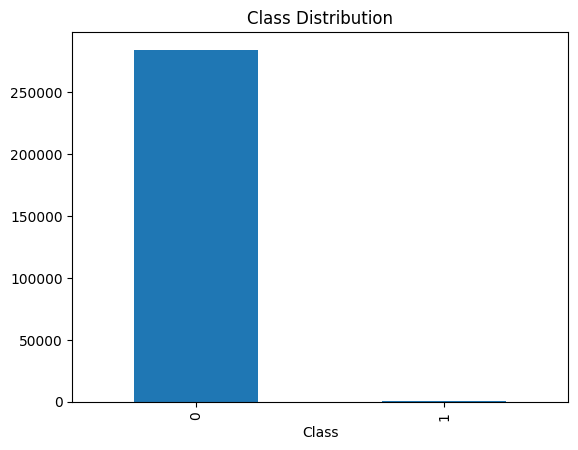

In [ ]:
import matplotlib.pyplot as plt

#Class Distribution
fraud_file['Class'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.show()


The class distribution analysis shows a severe imbalance in the dataset:

* 99.83% of transactions are legitimate (Class = 0)
* 0.17% of transactions are fraudulent (Class = 1)

This is also reflected in the bar chart, where the non-fraudulent class overwhelmingly dominates the dataset. This imbalance is a critical characteristic of the problem and has several implications:

* A model could achieve very high accuracy by simply predicting the majority class, making accuracy an unreliable metric
* Special attention will be needed in model evaluation, with a focus on metrics such as precision, recall, and F1-score
* Techniques such as resampling (e.g., oversampling the minority class or undersampling the majority class) or cost-sensitive learning may be required to effectively detect fraudulent transactions

In [ ]:
#Amount Distribution
print('\nAmount Distribution:')
print(fraud_file['Amount'].value_counts(normalize=True).nlargest(10))


Amount Distribution:
Amount
1.00     0.048061
1.98     0.021221
0.89     0.017106
9.99     0.016667
15.00    0.011517
0.76     0.010526
10.00    0.010358
1.29     0.010154
1.79     0.009210
0.99     0.008090
Name: proportion, dtype: float64


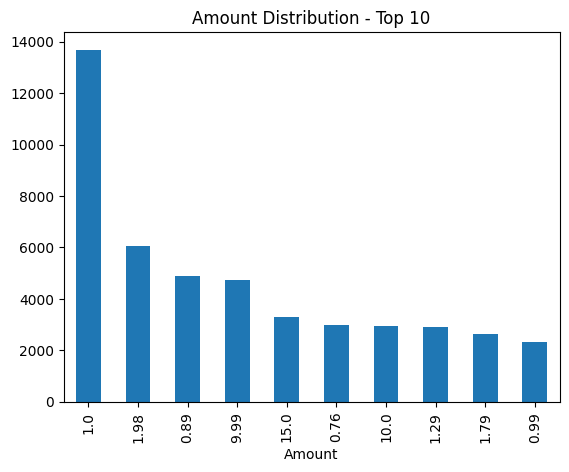

In [ ]:
fraud_file['Amount'].value_counts().nlargest(10).plot(kind='bar')
plt.title('Amount Distribution - Top 10')
plt.show()

The analysis of the Amount feature shows the most frequently occurring transaction values in the dataset. The top 10 most common amounts include values such as 1.00, 1.98, 0.89, and 9.99, with 1.00 alone accounting for approximately 4.8% of all transactions.

This indicates that:

* Many transactions are small-value purchases, which is typical in real-world credit card usage
* Certain price points (e.g., 0.99, 1.00, 9.99) appear frequently, likely reflecting common retail pricing patterns

However, this analysis does not fully represent the overall distribution of transaction amounts. Instead, it highlights repeated values. A more complete understanding would require examining:

* The spread and skewness of the data (e.g., using a histogram or boxplot)
* Whether large transactions are more associated with fraudulent activity

### Dataset Summary

In [ ]:
# #Dataset Summary
print('\nDataset Summary:')
fraud_file.describe()


Dataset Summary:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Summary statistics were generated using the .describe() function to understand the distribution and scale of the dataset’s features.

From the summary:

* The PCA-transformed features (V1–V28) have means very close to 0 and relatively consistent standard deviations, confirming that they are standardized and centered, as expected from PCA transformation
* The Amount feature shows significant variability:
  * Mean ≈ 88.35, but median ≈ 22.00
  * Maximum value ≈ 25,691, which is substantially higher than the 75th percentile (~77)
  * This indicates a highly right-skewed distribution with extreme outliers
* The Time feature ranges from 0 to 172,792 seconds, confirming that transactions span the full two-day period
* The Class variable has a mean of 0.0017, reinforcing the earlier observation of severe class imbalance

These findings suggest that:
* Most features are already scaled due to PCA, reducing preprocessing requirements
* The Amount feature may require additional scaling or transformation due to skewness and outliers
* The dataset’s imbalance and presence of extreme values will need to be carefully handled during modeling

## **Algorithms**

### **Task:**
This is a binary classification task, for which we will be utilizing both supervised and unsupervised models in the prediction process.

### **Models and Strategy:**
The pipeline will be structured in the following way. Original unsupervised anomaly scores/labels will be generated based off the data using an Isolation Forest. These labels will then be concatenated to the dataset as an additional feature fed to the supervised models, along with the correct labels. The supervised models used will be Log Regression and XGBoost.

Stratified K-Fold will be used to ensure that the ratio of fraud to non-fraud is preserved across training and testing.

As the default .5 threshold used in Log Reg and XGBoost is often unoptimal for fraud detection, tuning of the threshold will be conducted to improve model accuracy.

### **Reasoning For Model Selection:**

**Logistic Regression (Baseline)** - Provides a strong baseline for binary classification (fraud vs not fraud) with results that can be interpreted directly. Helps determine if the problem is linearly seperable.

**XGBoost (Primary Performance)** - Able to capture complex non-linear relationships (common in fraud problems), handles tabular data very well

**Isolation Forest (Unsupervised Signal)** - Detects "unusual" interactions without needing labeled data, provides anomally scores/labels that can be used as an additional feature for supervised models, and captures unseen fraud patterns in new data.

### **Evaluation Strategy:**

**AUC-ROC** - Measures how well models perform across all thresholds, and is not fooled by class imbalance. Can apppear deceptively optimistic as it accounts for true negatives.

**Precision-Recall Curve + AUC-PR** - Focused only on the positive fraud cases, which is the focus of our prediction task.

**F1 Score** - Single summary number balancing precision and recall.